In [2]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])

0

In [3]:
# CELLULE 1 - Imports et chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement des données
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

# Chargement du meilleur modele
xgb = joblib.load('../models/xgboost.joblib')

# Noms des features
FEATURE_NAMES = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                 'pressure_level', 'rpm', 'hours_since_maintenance', 
                 'ambient_temp', 'machine_type_CNC', 'machine_type_Compressor',
                 'machine_type_Pump', 'machine_type_Robotic Arm',
                 'operating_mode_idle', 'operating_mode_normal', 
                 'operating_mode_peak']

print(f"Modele charge : {type(xgb).__name__}")
print(f"Features : {len(FEATURE_NAMES)}")

Modele charge : XGBClassifier
Features : 14


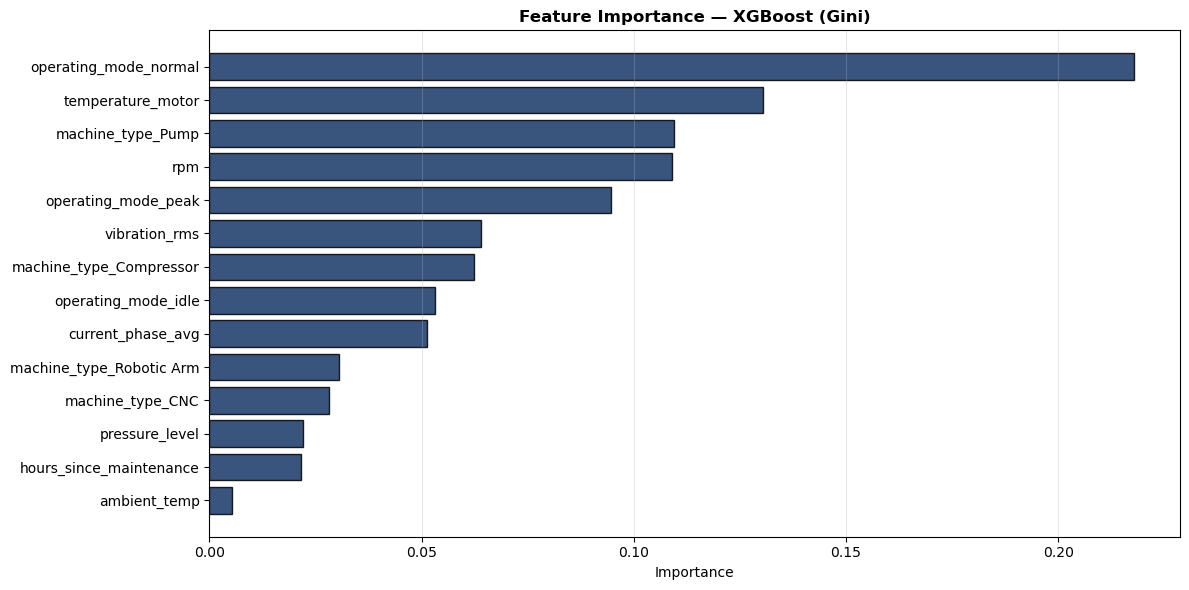

Top 5 features les plus importantes :
  1. operating_mode_normal : 0.2178
  2. temperature_motor : 0.1304
  3. machine_type_Pump : 0.1094
  4. rpm : 0.1091
  5. operating_mode_peak : 0.0946


In [4]:
# CELLULE 2 - Feature Importance native XGBoost
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh([FEATURE_NAMES[i] for i in indices[::-1]], 
               importances[indices[::-1]], 
               color=COLOR_BLUE, edgecolor='black', alpha=0.85)
ax.set_title('Feature Importance — XGBoost (Gini)', fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features les plus importantes :")
for i in range(5):
    print(f"  {i+1}. {FEATURE_NAMES[indices[i]]} : {importances[indices[i]]:.4f}")

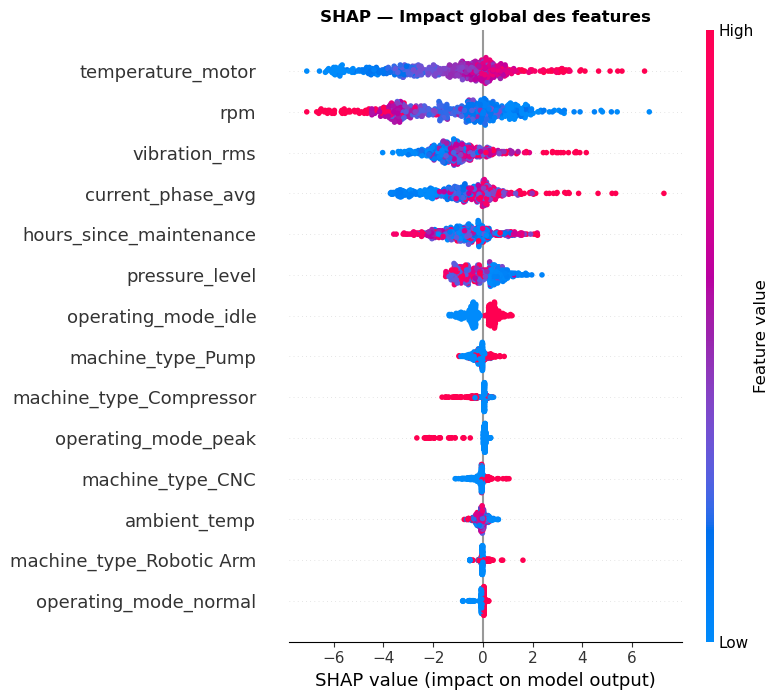

In [5]:
# CELLULE 3 - SHAP Values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:500])

# Summary plot global
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_values, X_test[:500], 
                  feature_names=FEATURE_NAMES,
                  show=False)
plt.title('SHAP — Impact global des features', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

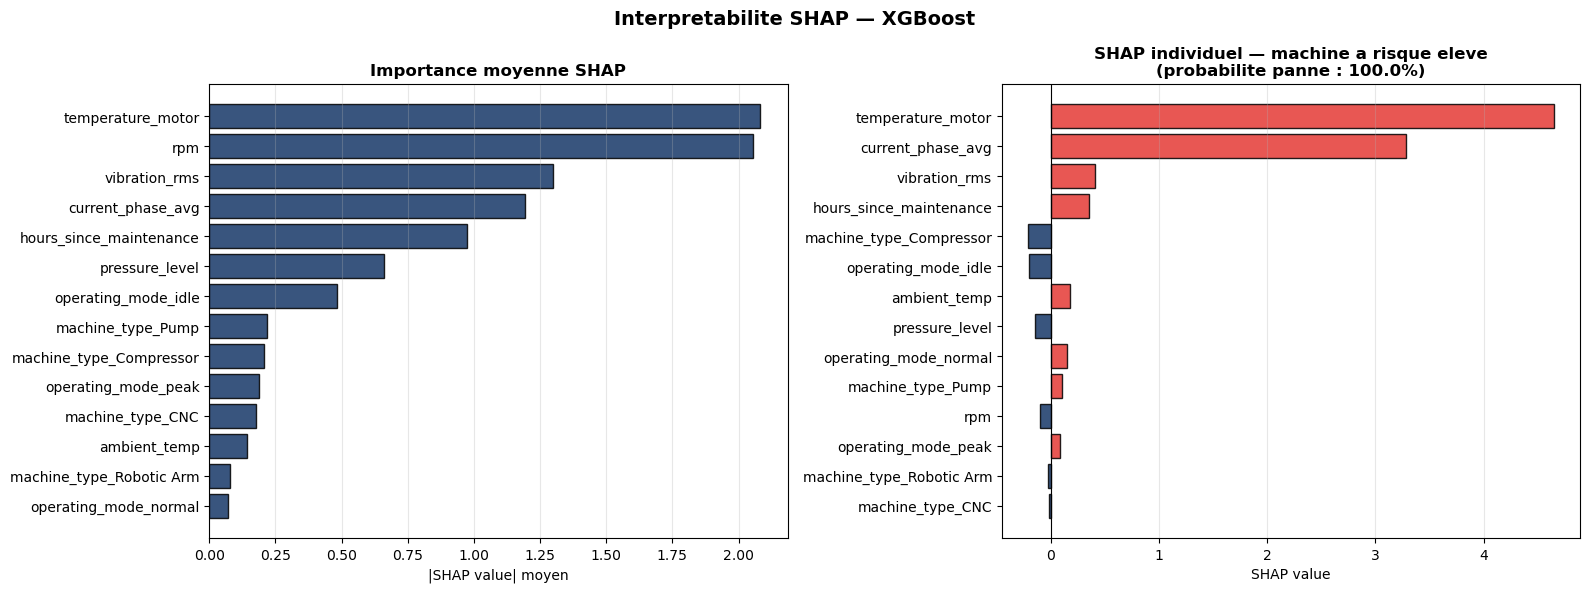

In [6]:
# CELLULE 4 - SHAP Bar plot + exemple individuel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot importance moyenne SHAP
shap_mean = np.abs(shap_values).mean(axis=0)
indices = np.argsort(shap_mean)
axes[0].barh([FEATURE_NAMES[i] for i in indices],
             shap_mean[indices], color=COLOR_BLUE, edgecolor='black', alpha=0.85)
axes[0].set_title('Importance moyenne SHAP', fontweight='bold')
axes[0].set_xlabel('|SHAP value| moyen')
axes[0].grid(axis='x', alpha=0.3)

# Exemple individuel - machine à risque élevé
y_proba = xgb.predict_proba(X_test[:500])[:,1]
idx_high_risk = np.argmax(y_proba)
shap_single = shap_values[idx_high_risk]
indices_single = np.argsort(np.abs(shap_single))

colors = [COLOR_RED if v > 0 else COLOR_BLUE for v in shap_single[indices_single]]
axes[1].barh([FEATURE_NAMES[i] for i in indices_single],
             shap_single[indices_single], color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'SHAP individuel — machine a risque eleve\n(probabilite panne : {y_proba[idx_high_risk]:.1%})', 
                  fontweight='bold')
axes[1].set_xlabel('SHAP value')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Interpretabilite SHAP — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()